# Proyecto Final - Notebook 05
## Comparacion de inferencia: `Greedy` vs `Beam Search`

Este notebook compara dos estrategias de decodificacion sobre el mejor modelo ya entrenado:
- `greedy decoding`: escoge la palabra mas probable en cada paso,
- `beam search`: conserva varias secuencias candidatas y escoge la mejor frase acumulada.

Motivacion:
- no requiere reentrenar el modelo,
- esta directamente alineado con lo visto en clase en la semana 8,
- puede mejorar la calidad final del caption aunque la red sea la misma.

Criterio de comparacion:
1. `BLEU-1` y `BLEU-2`,
2. ejemplos cualitativos de captions,
3. tiempo promedio de inferencia.


In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
import json
import os
import pickle
import time
from tempfile import gettempdir

os.environ.setdefault('MPLCONFIGDIR', str(Path(gettempdir()) / 'matplotlib-cache-project-final'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.image import imread
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

In [3]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
IMG_DIR = ROOT / 'data' / 'raw' / 'Images'
OUTPUT_DIR = ROOT / 'outputs' / 'predictions'

CAPTIONS_CLEAN_PATH = PROCESSED_DIR / 'captions_clean_split.csv'
SUMMARY_PATH = PROCESSED_DIR / 'preprocessing_summary.json'
TOKENIZER_JSON_PATH = PROCESSED_DIR / 'tokenizer.json'
FEATURES_PATH = PROCESSED_DIR / 'image_features_mobilenetv2.pkl'
CALIBRATION_RESULTS_PATH = OUTPUT_DIR / 'calibration_results_final.csv'

print('ROOT =', ROOT)
print('CALIBRATION_RESULTS_PATH =', CALIBRATION_RESULTS_PATH)

ROOT = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning
CALIBRATION_RESULTS_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/outputs/predictions/calibration_results_final.csv


In [4]:
df = pd.read_csv(CAPTIONS_CLEAN_PATH)
with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    preprocessing_summary = json.load(f)
with open(FEATURES_PATH, 'rb') as f:
    image_features = pickle.load(f)

tokenizer = tokenizer_from_json(TOKENIZER_JSON_PATH.read_text(encoding='utf-8'))

vocab_size = len(tokenizer.word_index) + 1
max_len = int(preprocessing_summary['max_len'])

test_df = df[df['split'] == 'test'].copy()

calibration_df = pd.read_csv(CALIBRATION_RESULTS_PATH)
final_model_row = calibration_df.iloc[0].copy()
FINAL_MODEL_PATH = Path(final_model_row['model_path'])

print('Modelo final seleccionado =', final_model_row['model_name'])
print('FINAL_MODEL_PATH =', FINAL_MODEL_PATH)
print('vocab_size =', vocab_size)
print('max_len =', max_len)
print('test captions =', len(test_df))

Modelo final seleccionado = lstm_256
FINAL_MODEL_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/models/calibration_lstm_256.keras
vocab_size = 7251
max_len = 38
test captions = 6075


In [5]:
model = load_model(FINAL_MODEL_PATH)
index_word = tokenizer.index_word
start_token = tokenizer.word_index['startseq']
end_token = tokenizer.word_index['endseq']

print(model.summary())

Metal device set to: Apple M1 Max

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB



2026-03-14 19:32:04.604021: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-14 19:32:04.604128: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 partial_caption (InputLayer)   [(None, 38)]         0           []                               
                                                                                                  
 image_features (InputLayer)    [(None, 1280)]       0           []                               
                                                                                                  
 caption_embedding (Embedding)  (None, 38, 256)      1856256     ['partial_caption[0][0]']        
                                                                                                  
 dropout (Dropout)              (None, 1280)         0           ['image_features[0][0]']         
                                                                                              

## 1. Funciones de inferencia

`Greedy` usa la mejor palabra local en cada paso.

`Beam Search` mantiene las `k` mejores secuencias parciales usando suma de log-probabilidades. Esto permite corregir decisiones tempranas y escoger frases globalmente mas consistentes.

In [6]:
def decode_tokens(token_ids, index_word, start_token, end_token):
    words = [index_word.get(idx, 'unk') for idx in token_ids if idx not in (start_token, end_token, 0)]
    return ' '.join(words)


def get_reference_captions(image_name, dataframe):
    refs = dataframe.loc[dataframe['image'] == image_name, 'caption_clean'].tolist()
    refs = [caption.replace('startseq ', '').replace(' endseq', '') for caption in refs]
    return refs


def greedy_caption(image_name, model, image_features, max_len):
    feature_vector = image_features[image_name].reshape(1, -1)
    seq = [start_token]

    for _ in range(max_len):
        padded_seq = pad_sequences([seq], maxlen=max_len, padding='post')
        yhat = model.predict([feature_vector, padded_seq], verbose=0)[0]
        next_idx = int(np.argmax(yhat))

        if next_idx in (0, end_token):
            break
        seq.append(next_idx)

    return decode_tokens(seq, index_word, start_token, end_token)


def beam_search_caption(image_name, model, image_features, max_len, beam_width=3):
    feature_vector = image_features[image_name].reshape(1, -1)
    sequences = [([start_token], 0.0)]

    for _ in range(max_len):
        all_candidates = []
        all_ended = True

        for seq, score in sequences:
            if seq[-1] == end_token:
                all_candidates.append((seq, score))
                continue

            all_ended = False
            padded_seq = pad_sequences([seq], maxlen=max_len, padding='post')
            yhat = model.predict([feature_vector, padded_seq], verbose=0)[0]

            # Evitar padding y probabilidades cero para que el log-score sea estable.
            candidate_indices = np.argsort(yhat)[-beam_width:][::-1]
            for next_idx in candidate_indices:
                if int(next_idx) == 0:
                    continue
                prob = float(yhat[int(next_idx)])
                if prob <= 0.0:
                    continue
                candidate = (seq + [int(next_idx)], score + np.log(prob + 1e-12))
                all_candidates.append(candidate)

        if not all_candidates:
            break

        sequences = sorted(all_candidates, key=lambda item: item[1], reverse=True)[:beam_width]
        if all_ended:
            break

    best_seq = sequences[0][0]
    if best_seq and best_seq[-1] == end_token:
        return decode_tokens(best_seq, index_word, start_token, end_token)
    return decode_tokens(best_seq, index_word, start_token, end_token)

2026-03-14 19:32:05.728255: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-03-14 19:32:06.168607: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 19:32:07.173052: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


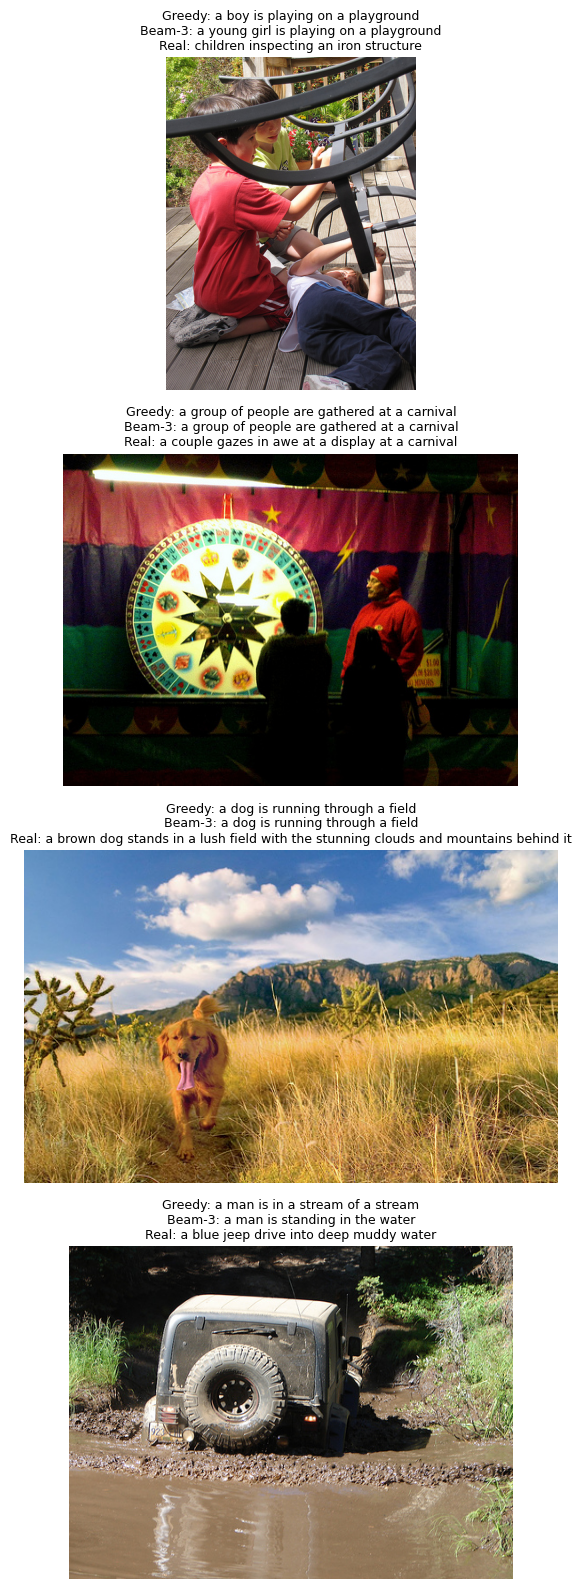

In [7]:
sample_images = test_df['image'].drop_duplicates().sample(4, random_state=42).tolist()

fig, axes = plt.subplots(len(sample_images), 1, figsize=(12, 4 * len(sample_images)))
axes = np.atleast_1d(axes)

for ax, image_name in zip(axes, sample_images):
    pred_greedy = greedy_caption(image_name, model, image_features, max_len)
    pred_beam = beam_search_caption(image_name, model, image_features, max_len, beam_width=3)
    ref = get_reference_captions(image_name, test_df)[0]

    ax.imshow(imread(IMG_DIR / image_name))
    ax.set_title(f"Greedy: {pred_greedy}\nBeam-3: {pred_beam}\nReal: {ref}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'beam_search_qualitative_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Evaluacion cuantitativa

Se compara `Greedy`, `Beam-3` y `Beam-5` sobre una muestra del conjunto de test para medir si la estrategia de inferencia mejora el caption final.

In [8]:
eval_images = test_df['image'].drop_duplicates().tolist()[:300]
strategies = [
    ('greedy', lambda image_name: greedy_caption(image_name, model, image_features, max_len)),
    ('beam_3', lambda image_name: beam_search_caption(image_name, model, image_features, max_len, beam_width=3)),
    ('beam_5', lambda image_name: beam_search_caption(image_name, model, image_features, max_len, beam_width=5)),
]

rows = []
qual_rows = []

for strategy_name, caption_fn in strategies:
    references = []
    hypotheses = []
    start_time = time.perf_counter()

    for image_name in eval_images:
        refs = [caption.split() for caption in get_reference_captions(image_name, test_df)]
        hyp_text = caption_fn(image_name)
        hyp = hyp_text.split()
        references.append(refs)
        hypotheses.append(hyp)
        if len(qual_rows) < len(sample_images) * len(strategies) and image_name in sample_images:
            qual_rows.append({'image': image_name, 'strategy': strategy_name, 'prediction': hyp_text, 'reference_1': get_reference_captions(image_name, test_df)[0]})

    elapsed = time.perf_counter() - start_time
    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)

    rows.append({
        'strategy': strategy_name,
        'BLEU-1': round(bleu1, 4),
        'BLEU-2': round(bleu2, 4),
        'eval_images': len(eval_images),
        'total_inference_sec': round(elapsed, 2),
        'sec_per_image': round(elapsed / len(eval_images), 4)
    })

beam_results_df = pd.DataFrame(rows).sort_values(['BLEU-2', 'BLEU-1'], ascending=False).reset_index(drop=True)
beam_results_df.to_csv(OUTPUT_DIR / 'beam_search_results.csv', index=False)
beam_results_df

,strategy,BLEU-1,BLEU-2,eval_images,total_inference_sec,sec_per_image
0,beam_5,0.6306,0.4495,300,549.80,1.8327
1,beam_3,0.6222,0.4354,300,340.48,1.1349
2,greedy,0.6130,0.4244,300,110.48,0.3683


In [9]:
qual_df = pd.DataFrame(qual_rows).sort_values(['image', 'strategy']).reset_index(drop=True)
qual_df.to_csv(OUTPUT_DIR / 'beam_search_qualitative_examples.csv', index=False)
qual_df.head(12)

,image,strategy,prediction,reference_1
0,1324816249_86600a6759.jpg,beam_3,a dog is running through a field,a brown dog stands in a lush field with the st...
1,1324816249_86600a6759.jpg,beam_5,a dog is running through a field,a brown dog stands in a lush field with the st...
2,1324816249_86600a6759.jpg,greedy,a dog is running through a field,a brown dog stands in a lush field with the st...
3,210625425_fb1ef5d23b.jpg,beam_3,a man is standing in the water,a blue jeep drive into deep muddy water
4,210625425_fb1ef5d23b.jpg,beam_5,a man is standing in the water,a blue jeep drive into deep muddy water
5,210625425_fb1ef5d23b.jpg,greedy,a man is in a stream of a stream,a blue jeep drive into deep muddy water


## 3. Interpretacion esperada

- si `Beam Search` mejora `BLEU`, se puede usar como estrategia final de inferencia aunque el modelo entrenado sea el mismo,
- si la mejora es pequena, aun asi es defendible como refinamiento metodologico visto en clase,
- si `Greedy` y `Beam Search` empatan, se puede priorizar `Greedy` por simplicidad y menor costo de inferencia.
